***STEP 1 - Import librerie e recap caratteristiche dataset***

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset_clean.csv")

print(f"Righe: {len(df):,}")
print(f"Colonne: {list(df.columns)}")
print(f"\nDistribuzione priorita_finale:")
print(df['priorita_finale'].value_counts().sort_index())
print(f"\nNaN per colonna:")
print(df.isnull().sum())

Righe: 58,385
Colonne: ['url_ticket', 'case_number', 'testo_input', 'priorita_finale', 'priorita_iniziale_cliente', 'area', 'articolo', 'modulo_sw', 'has_urgenza', 'n_parole', 'data_creazione']

Distribuzione priorita_finale:
priorita_finale
P1     8131
P2    16998
P3    31783
P4     1473
Name: count, dtype: int64

NaN per colonna:
url_ticket                      0
case_number                     0
testo_input                     0
priorita_finale                 0
priorita_iniziale_cliente       0
area                         5847
articolo                     5879
modulo_sw                    5805
has_urgenza                     0
n_parole                        0
data_creazione                  0
dtype: int64


***STEP 2 — Split temporale train/test***

In [6]:
# Converto data_creazione in datetime
df['data_creazione'] = pd.to_datetime(df['data_creazione'])

# Soglia di split: 1 Novembre 2025
SOGLIA = pd.Timestamp('2025-11-01')

df_train = df[df['data_creazione'] < SOGLIA].copy()
df_test  = df[df['data_creazione'] >= SOGLIA].copy()

print(f"Train: {len(df_train):,} ticket ({len(df_train)/len(df)*100:.1f}%)")
print(f"Test:  {len(df_test):,} ticket ({len(df_test)/len(df)*100:.1f}%)")

print(f"\nTrain — distribuzione priorita_finale:")
print(df_train['priorita_finale'].value_counts().sort_index())

print(f"\nTest — distribuzione priorita_finale:")
print(df_test['priorita_finale'].value_counts().sort_index())

Train: 46,353 ticket (79.4%)
Test:  12,032 ticket (20.6%)

Train — distribuzione priorita_finale:
priorita_finale
P1     6510
P2    13665
P3    24958
P4     1220
Name: count, dtype: int64

Test — distribuzione priorita_finale:
priorita_finale
P1    1621
P2    3333
P3    6825
P4     253
Name: count, dtype: int64


***STEP 3 — Preprocessing features***

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp

# Colonne categoriche e booleane
CAT_COLS  = ['priorita_iniziale_cliente']
BOOL_COLS = ['has_urgenza']

# Sostituisco i NaN nelle categoriche con "sconosciuto"
for col in CAT_COLS:
    df_train[col] = df_train[col].fillna('sconosciuto')
    df_test[col]  = df_test[col].fillna('sconosciuto')

# One-Hot Encoding — fit solo su train, transform su entrambi
# handle_unknown='ignore': se nel test appare una categoria
# mai vista nel train, la ignora invece di dare errore
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoder.fit(df_train[CAT_COLS])

X_cat_train = encoder.transform(df_train[CAT_COLS])
X_cat_test  = encoder.transform(df_test[CAT_COLS])

# Feature booleane — già 0/1, le convertiamo in matrice sparsa
X_bool_train = sp.csr_matrix(df_train[BOOL_COLS].values)
X_bool_test  = sp.csr_matrix(df_test[BOOL_COLS].values)

print(f"Feature categoriche encoded: {X_cat_train.shape[1]} colonne")
print(f"Feature booleane:            {X_bool_train.shape[1]} colonne")

Feature categoriche encoded: 4 colonne
Feature booleane:            1 colonne


***STEP 4 — Embedding del testo con Sentence Transformer***

In [ ]:
from sentence_transformers import SentenceTransformer

# Carico il modello multilingue
# paraphrase-multilingual-mpnet-base-v2 è addestrato su 50 lingue
# incluso l'italiano, e produce vettori da 768 dimensioni
modello = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

print("Calcolo embedding train...")
X_text_train = modello.encode(
    df_train['testo_input'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print("Calcolo embedding test...")
X_text_test = modello.encode(
    df_test['testo_input'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print(f"\nShape embedding train: {X_text_train.shape}")
print(f"Shape embedding test:  {X_text_test.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calcolo embedding train...


Batches:   0%|          | 0/725 [00:00<?, ?it/s]

Calcolo embedding test...


Batches:   0%|          | 0/188 [00:00<?, ?it/s]


Shape embedding train: (46353, 768)
Shape embedding test:  (12032, 768)


In [8]:
'''# Salvo embedding modello attuale (paraphrase-multilingual-mpnet-base-v2)
np.save('X_text_train_mpnet.npy', X_text_train)
np.save('X_text_test_mpnet.npy', X_text_test)
print("Embedding mpnet salvati ✅")'''

# Ricarico embedding da file (per dimostrare che funziona)
X_text_train = np.load('X_text_train_mpnet.npy')
X_text_test  = np.load('X_text_test_mpnet.npy')
print("Embedding mpnet caricati ✅")

Embedding mpnet caricati ✅


***STEP 5 — Unione di tutte le feature in un'unica matrice***

In [10]:
import scipy.sparse as sp
import numpy as np

# Converto gli embedding (numpy array) in matrice sparsa
# per renderli compatibili con X_cat e X_bool che sono già sparse
X_text_train_sp = sp.csr_matrix(X_text_train)
X_text_test_sp  = sp.csr_matrix(X_text_test)

# hstack = horizontal stack — unisce le matrici colonna per colonna
X_train = sp.hstack([X_text_train_sp, X_cat_train, X_bool_train])
X_test  = sp.hstack([X_text_test_sp,  X_cat_test,  X_bool_test])

# Target
y_train = df_train['priorita_finale'].values
y_test  = df_test['priorita_finale'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train classi: {np.unique(y_train)}")

X_train shape: (46353, 773)
X_test shape:  (12032, 773)
y_train classi: ['P1' 'P2' 'P3' 'P4']


In [12]:
# STEP 6 — Training classificatore priorità
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# class_weight='balanced' — compensa lo sbilanciamento tra classi
# max_iter=2000 — aumentiamo le iterazioni per garantire convergenza
clf = LinearSVC(class_weight='balanced', max_iter=2000, C=1.0)
clf.fit(X_train, y_train)

# Valutazione sul test set
y_pred = clf.predict(X_test)

print("=== RISULTATI CLASSIFICATORE PRIORITÀ ===")
print(classification_report(y_test, y_pred))

=== RISULTATI CLASSIFICATORE PRIORITÀ ===
              precision    recall  f1-score   support

          P1       0.63      0.95      0.76      1621
          P2       0.87      0.80      0.84      3333
          P3       0.99      0.91      0.95      6825
          P4       0.97      0.74      0.84       253

    accuracy                           0.88     12032
   macro avg       0.86      0.85      0.84     12032
weighted avg       0.90      0.88      0.89     12032



In [ ]:
'''from sklearn.model_selection import cross_val_score

for c in [0.01, 0.1, 1.0, 5.0, 10.0]:
    clf_test = LinearSVC(class_weight='balanced', max_iter=2000, C=c)
    scores = cross_val_score(clf_test, X_train, y_train, 
                             cv=3, scoring='f1_macro', n_jobs=-1)
    print(f"C={c:5.2f} — Macro F1: {scores.mean():.4f} (+/- {scores.std():.4f})")'''

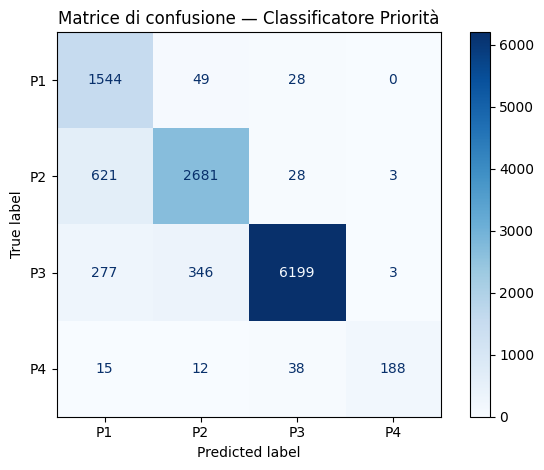

In [13]:
# Matrice di confusione
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=['P1', 'P2', 'P3', 'P4'],
    cmap='Blues'
)
plt.title('Matrice di confusione — Classificatore Priorità')
plt.tight_layout()
plt.show()

In [16]:
import numpy as np

# Indici corretti in base alle feature usate in questo run
n_emb  = 768
n_cat  = X_cat_train.shape[1]  # 0 se CAT_COLS è vuoto
n_bool = len(BOOL_COLS)        # 1 (has_urgenza)

for i, classe in enumerate(clf.classes_):
    coef = clf.coef_[i]
    
    peso_emb  = np.abs(coef[:n_emb]).mean()
    peso_cat  = np.abs(coef[n_emb:n_emb+n_cat]).mean() if n_cat > 0 else float('nan')
    peso_bool = np.abs(coef[n_emb+n_cat:n_emb+n_cat+n_bool]).mean() if n_bool > 0 else float('nan')

    print(f"\n{classe}")
    print(f"  Embedding (testo):     {peso_emb:.4f}")
    print(f"  Categoriche:           {peso_cat:.4f}")
    print(f"  has_urgenza:           {peso_bool:.4f}")


P1
  Embedding (testo):     0.4875
  Categoriche:           0.7854
  has_urgenza:           0.0422

P2
  Embedding (testo):     0.3118
  Categoriche:           0.7159
  has_urgenza:           0.0164

P3
  Embedding (testo):     0.1576
  Categoriche:           0.7432
  has_urgenza:           0.0423

P4
  Embedding (testo):     0.7105
  Categoriche:           1.0695
  has_urgenza:           0.1425
